In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import sys

sys.path.append("../src")

In [33]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np 
from games.prisoners_dilemma import play_round

# Games on network, figuring out implementation

## Testing a simple population and network example

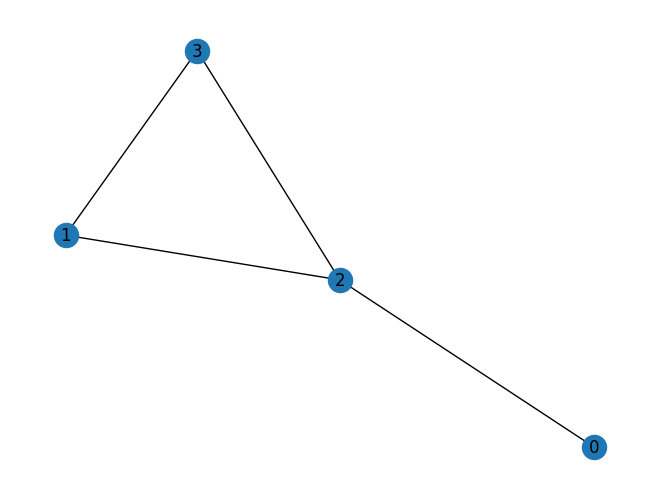

In [27]:
population = np.array([True, True, False, False])

G = nx.Graph()
G.add_nodes_from(range(len(population)))
G.add_edges_from([(1,2),(2,0),(3,2),(3,1)])

nx.draw(G, with_labels = True)

Now we have to compute 1's neighbours

In [ ]:
for i in range(len(population)):
    neighbors = list(G.neighbors(i))
    print(f"Node {i} has the following neighbors: {neighbors}")


Node 0 has the following neighbors: [2]
Node 1 has the following neighbors: [2, 3]
Node 2 has the following neighbors: [1, 0, 3]
Node 3 has the following neighbors: [2, 1]
[2, 3]


We have to modify our payoffs function so that agents only play with their neighbors.

In [ ]:
def total_payoffs_network(population):
    payoffs = np.zeros(len(population))

    for i, strategy_i in enumerate(population):
        for j in list(G.neighbors(i)):
            if i == j:
                continue
            payoff_i, payoff_j = play_round(population[i],population[j])
            payoffs[i] += payoff_i
            # print(f"Agent {i} vs Agent {j}: {population[i]} vs {population[j]} -> payoff_i={payoff_i}, accumulated={payoffs[i]}")
    return np.array(payoffs)

In [35]:
test = total_payoffs_network(population)

print(test)

[ 0.  0. 11.  6.]


To make sure that the model is working correctly, we can compute this example by hand.


### Agent A (Cooperator)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     C      |    CD     |   0     |
| **Total** |         |    0    |

### Agent B (Cooperator)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     C      |   CD      |   0     |
|     D     |     CD    |     0   |
| **Total** |         |        |

### Agent C (Defector)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     B      |   DC      |    5    |
|     A     |     DC    |    5    |
|     D     |    DD     |    1    |
| **Total** |         |     11   |

### Agent D (Defector)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     C      |    DD     |   1     |
|     B      |     DC    |     5   |
| **Total** |         |    6    |


Yes, it works.